In [1]:
import pandas as pd
from CCA_utils import *

##Baseline Model panel:

In [ ]:
study_sovereigns = [
    'Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia','Indonesia', 'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand']

cca_panel_df = pd.read_csv('../data/processed/CCA/cca_newfx_rates.csv')
cca_panel_df['date'] = pd.to_datetime(cca_panel_df['date'])
cca_panel_df = cca_panel_df[cca_panel_df['country'].isin(study_sovereigns)].copy()
cca_panel_df.drop(columns=['cds_spread_1Y'], inplace=True)
cca_panel_df.rename(columns={'cds_spread_5Y': 'cds_spread'}, inplace=True)


T=1.0
vol_window = 12
freq = 'ME'

cca_panel_df.set_index(['date','country'], inplace=True)
cca_panel_df = (
    cca_panel_df
    .groupby('country')
    .resample('ME', level='date')
    .last()
)
cca_panel_df.reset_index(inplace=True)
cca_panel_df['domestic_rate_in_units'] = cca_panel_df['domestic_rate_in_units']/100
cca_panel_df['risk_free_rate'] = cca_panel_df['risk_free_rate']/100
cca_panel_df['monetary_base_mn_localcurr'] = cca_panel_df['monetary_base_mn_localcurr'] / 1000
cca_panel_df['domestic_debt_bn_localcurr'] = cca_panel_df['domestic_debt_bn_localcurr']
cca_panel_df['external_debt_mn_usd'] = cca_panel_df['external_debt_mn_usd']/1000


In [39]:
results = pd.DataFrame()

for country, group in cca_panel_df.groupby('country'):

    df = group.copy().sort_values('date').reset_index(drop=True)
    
    # --- Unit conversions ---
    r_d = df['domestic_rate_in_units']
    r_f = df['risk_free_rate']
    M_bn = df['monetary_base_mn_localcurr']
    dom_D_bn = df['domestic_debt_bn_localcurr']
    ext_D_bn = df['external_debt_mn_usd']
    fx_rate = df['fx_rate']


    # --- LCL$ ---
    df['LCL_usd'] = [
        compute_lcl_usd(m, bd, fx, rd, rf, T)
        for m, bd, fx, rd, rf in zip(
            M_bn, dom_D_bn, fx_rate, r_d, r_f
        )
    ]

    ann_factor = np.sqrt(52) if freq == 'W' else np.sqrt(12)
    log_ret = np.log(df['LCL_usd'] / df['LCL_usd'].shift(1))
    df['sigma_lcl'] = log_ret.rolling(window=vol_window).std() * ann_factor
    
    # --- Barrier ---
    df['B_f'] = [
            compute_barrier_kvm(debt, rf, T)
            for debt, rf in zip(
                ext_D_bn, r_f
            )
        ]
    
    # --- Solve CCA for each week ---
    out = {'implied_V': [], 'implied_sigma_V': [], 'cca_converged': [],
           'distance_to_distress': [], 'default_prob': [],
           'model_spread_bps': [], 'put_value': [], 'risky_debt': [],
           'leverage': []}
    
    for i, row in df.iterrows():
        cca = solve_CCA(row['LCL_usd'], row['sigma_lcl'], row['B_f'],
                        r_f.iloc[i], T)
        

        risk = compute_risk(cca['V'], cca['sigma_V'], row['B_f'],
                            r_f.iloc[i], T)
        
        out['implied_V'].append(cca['V'])
        out['implied_sigma_V'].append(cca['sigma_V'])
        out['cca_converged'].append(cca['converged'])
        out['distance_to_distress'].append(risk['d2'])
        out['default_prob'].append(risk['default_prob'])
        out['model_spread_bps'].append(risk['credit_spread_bps'])
        out['put_value'].append(risk['put_value'])
        out['risky_debt'].append(risk['risky_debt'])
        out['leverage'].append(risk['leverage'])
    
    for col, vals in out.items():
        df[col] = vals

    results = pd.concat([results, df])



    START_DATE = '2015-01-01'
    END_DATE = '2019-12-31'

    results = results[
        (results['date'] >= START_DATE) & (results['date'] <= END_DATE)
    ].copy()

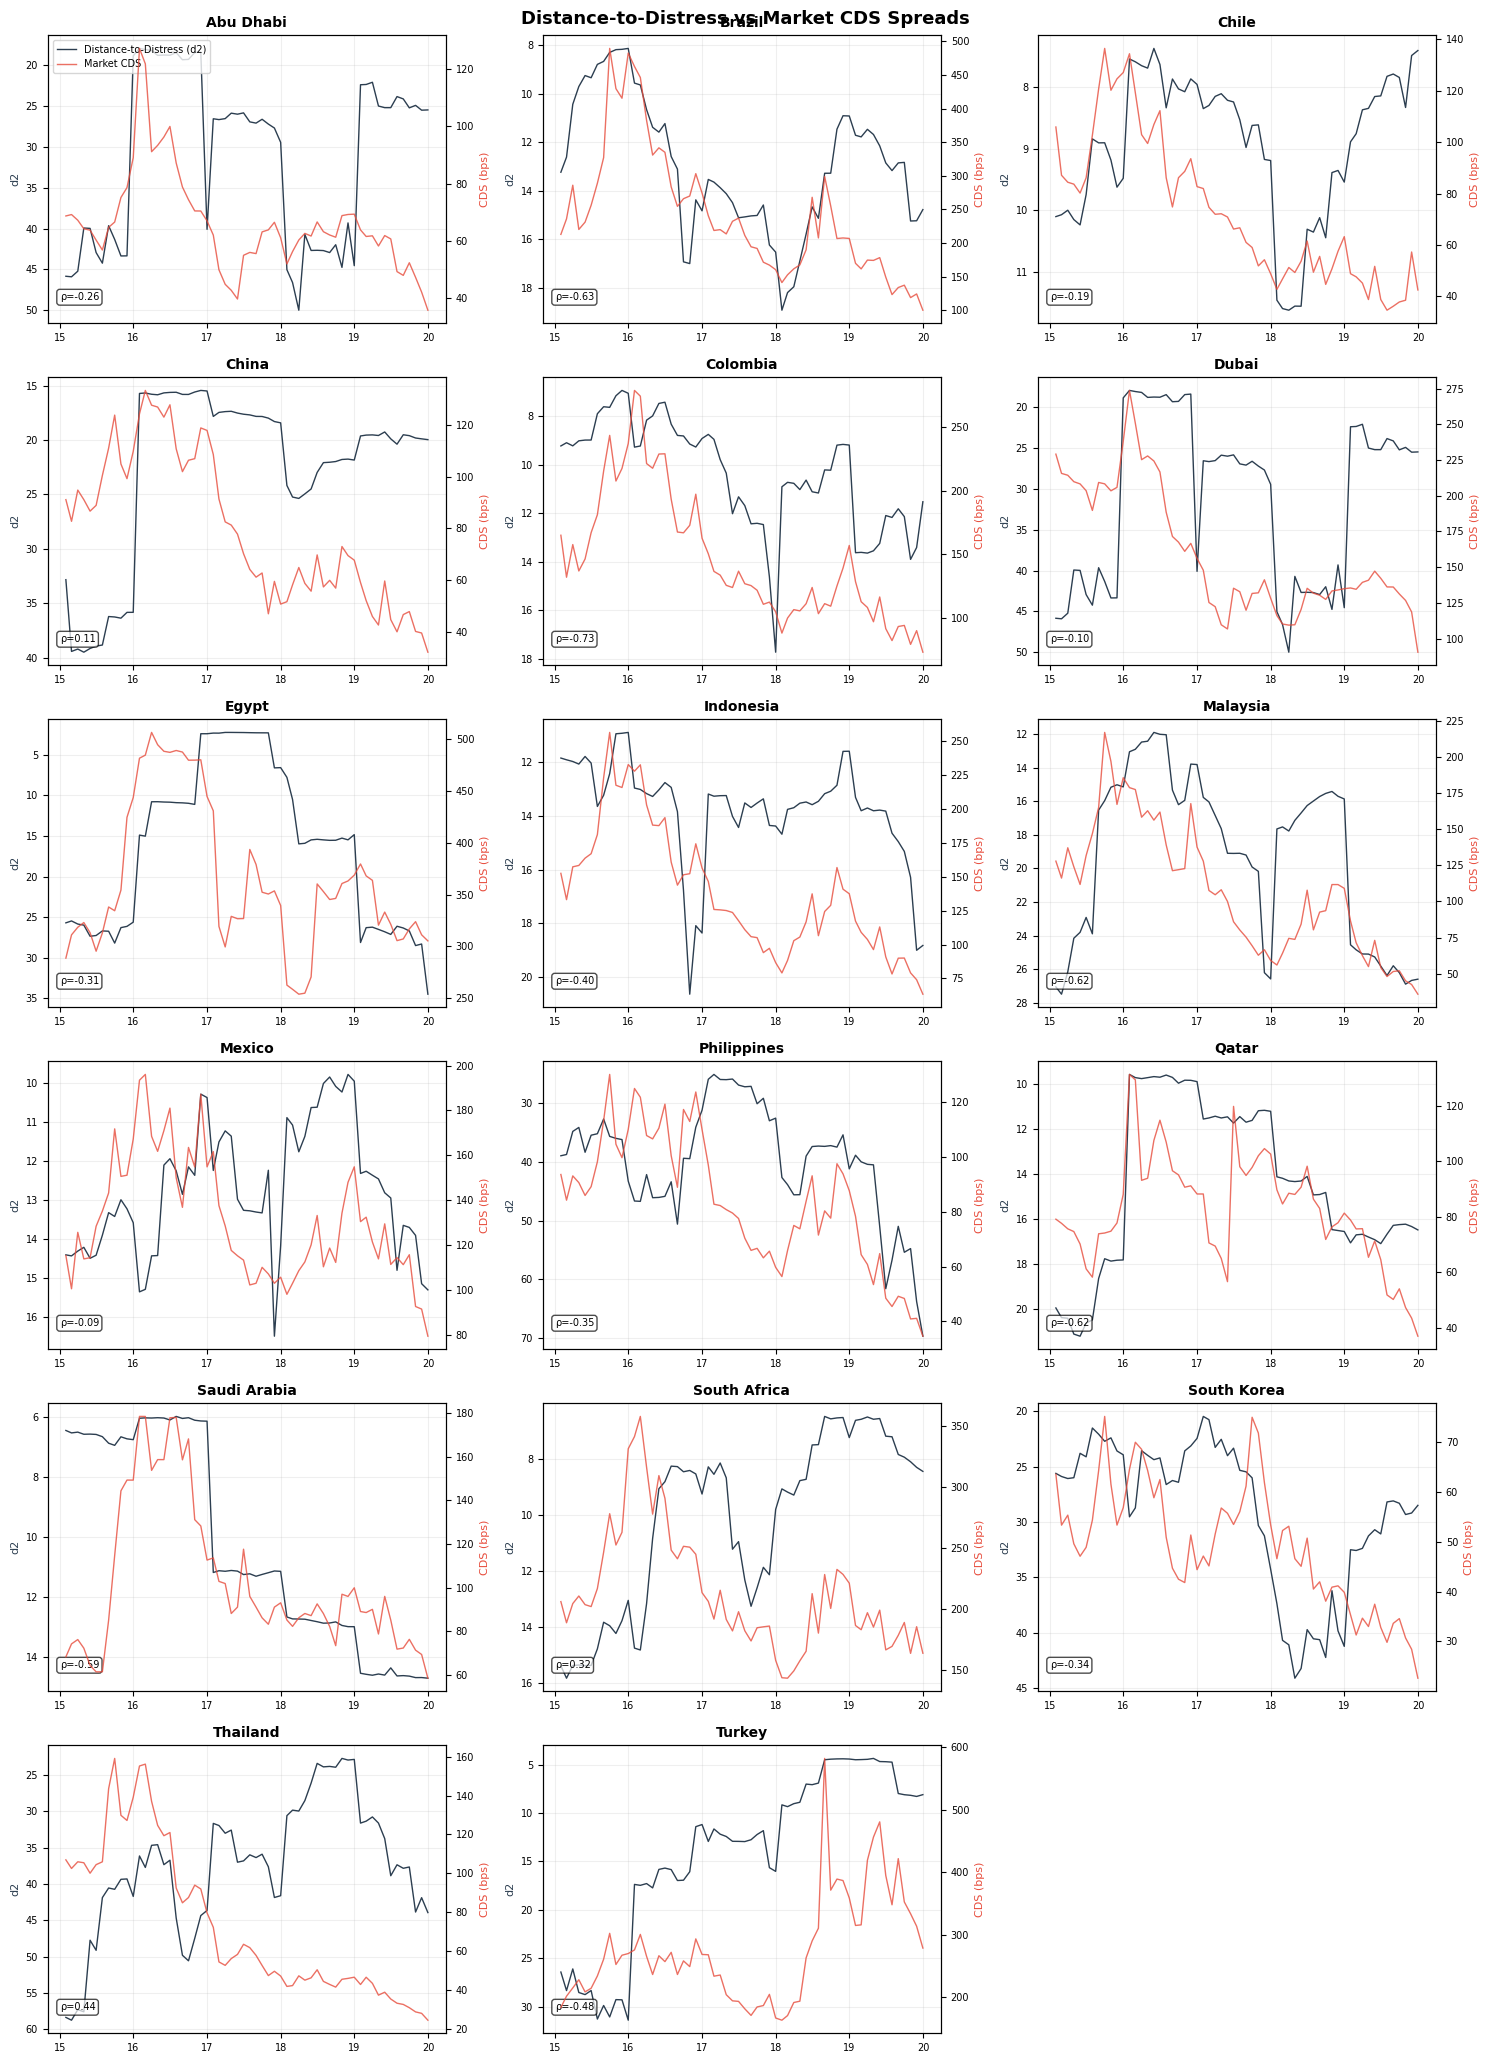

In [40]:
d2_vs_cds = plot_d2_vs_cds(results)

c:\Users\JuanFranciscoPerez\Projects\commodities_and_sovereigns\Chapter_02\CCA_utils.py:398: RuntimeWarning: overflow encountered in power
  return a * np.power(x, b)


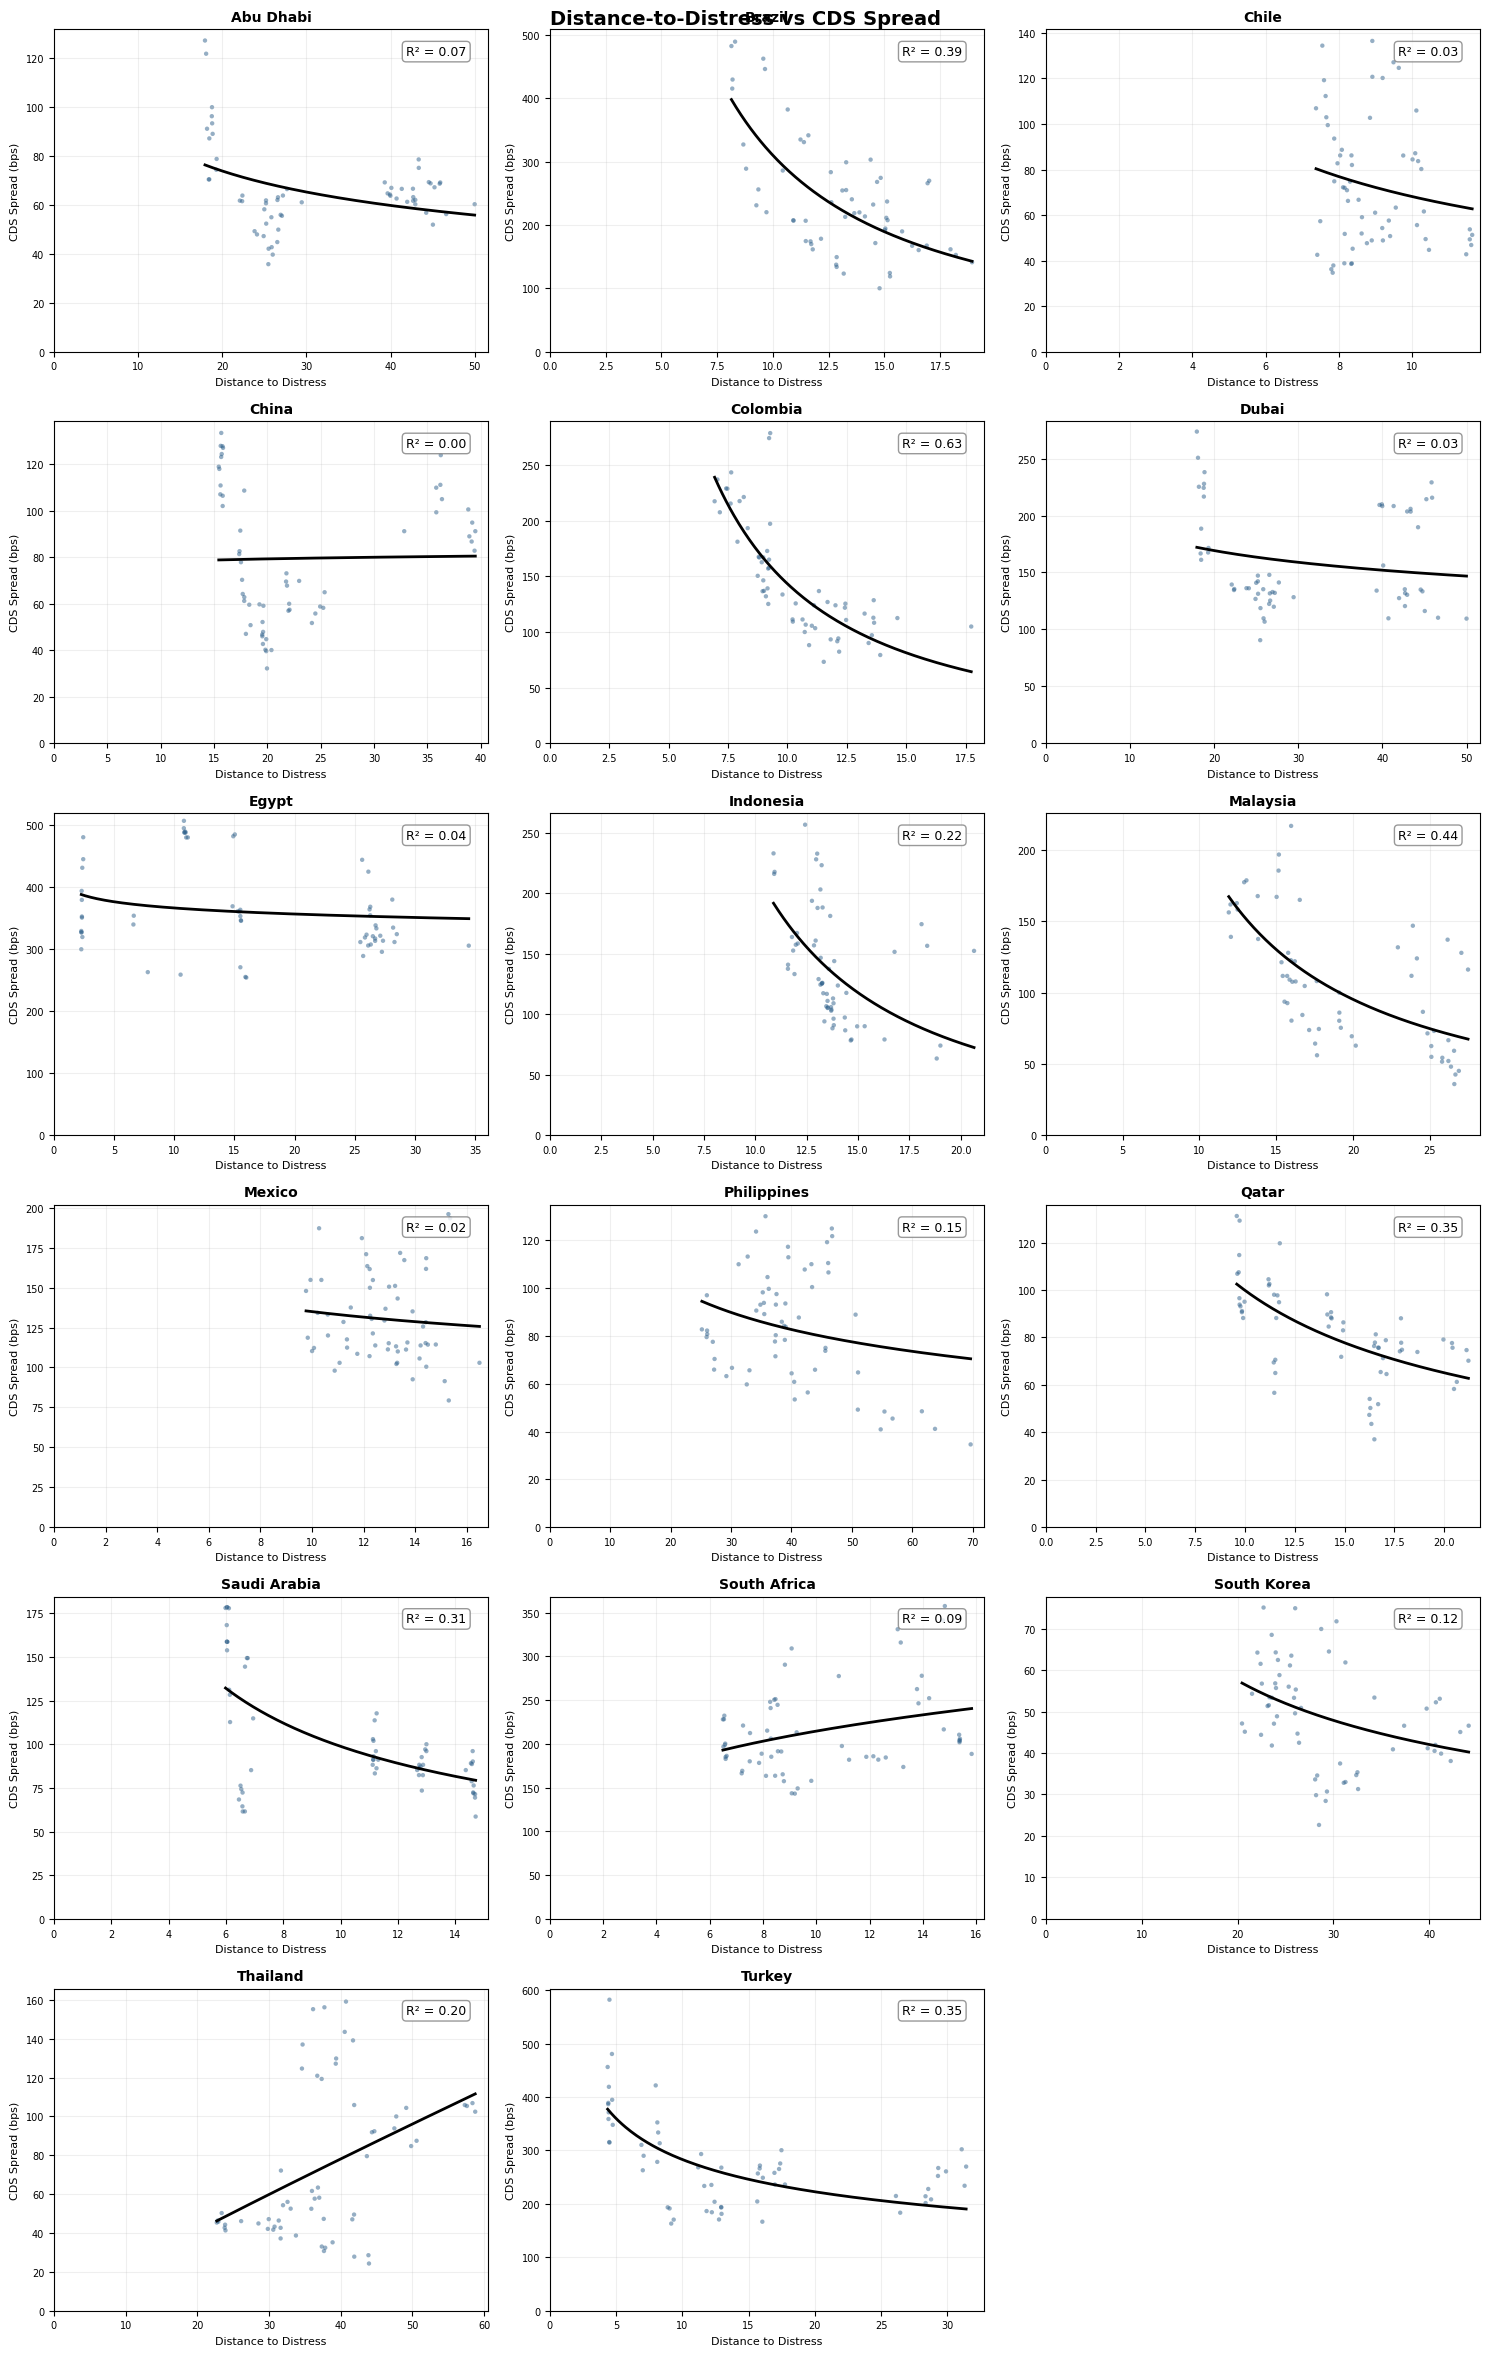

In [42]:
d2_scatter = plot_d2_scatter(results)

In [43]:
display, raw = correlation_table(
    results,
    dd_col='distance_to_distress',
    horizons=[1, 3, 6],
    horizon_labels=['1m', '3m', '6m'],
)
display

,Country,N,ρ (1m),ρ_S (1m),Dir (1m),ρ (3m),ρ_S (3m),Dir (3m),ρ (6m),ρ_S (6m),Dir (6m)
0,Abu Dhabi,60,-0.11,-0.00,49%,-0.39***,-0.16,53%,-0.47***,-0.37,59%
1,Brazil,60,-0.31**,-0.41,66%,-0.34***,-0.36,65%,-0.53***,-0.59,85%
2,Chile,60,-0.31**,-0.25,53%,-0.27**,-0.36,67%,-0.25*,-0.27,69%
3,China,60,-0.27**,-0.28,61%,-0.40***,-0.32,66%,-0.46***,-0.49,67%
4,Colombia,60,0.04,-0.02,58%,-0.13,-0.15,58%,-0.30**,-0.37,67%
5,Dubai,60,-0.29**,-0.16,61%,-0.46***,-0.27,58%,-0.54***,-0.54,72%
6,Egypt,60,-0.12,-0.16,56%,-0.26**,-0.27,60%,-0.27**,-0.24,54%
7,Indonesia,60,-0.04,-0.21,58%,-0.02,-0.14,61%,-0.22,-0.41,80%
8,Malaysia,60,-0.24*,-0.25,61%,-0.62***,-0.62,75%,-0.75***,-0.70,83%
9,Mexico,60,-0.07,-0.09,58%,-0.16,-0.25,61%,-0.28**,-0.27,70%


In [ ]:
results.to_csv("../output/results/M0_results.csv")